In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/UCI_Credit_Card.csv")

### Veri Keşfi

In [21]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [22]:
df.shape

(30000, 25)

In [24]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [25]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [29]:
df = df.drop(columns=["ID"])

### Görselleştirme

In [31]:
df["default.payment.next.month"].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

<Axes: xlabel='default.payment.next.month', ylabel='count'>

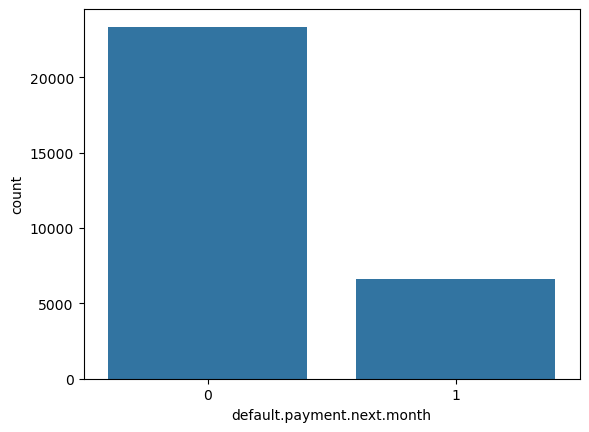

In [32]:
sns.countplot(x = df["default.payment.next.month"])

Text(0.5, 1.0, 'Yaşa göre ödeme dağılımı')

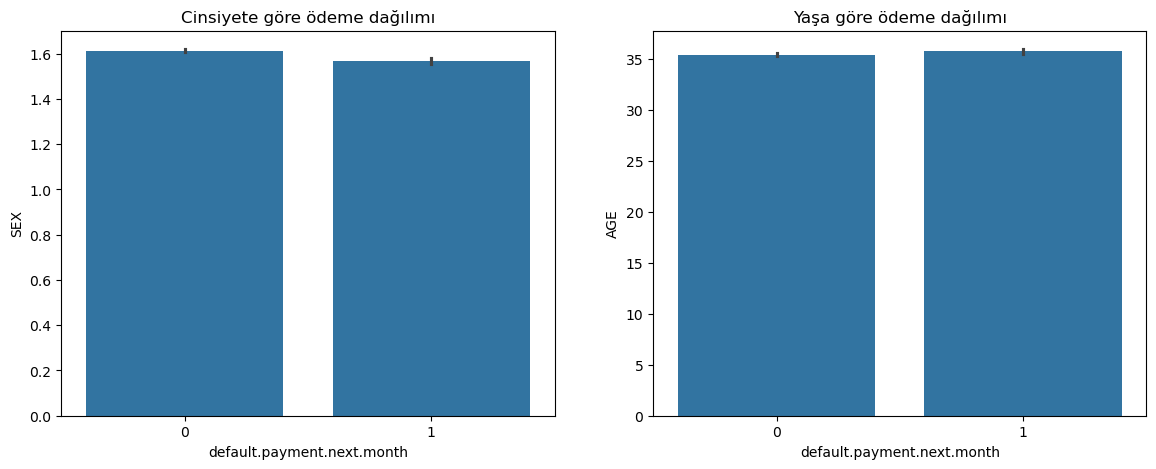

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.figsize = (8,6,0)
sns.barplot(x = df["default.payment.next.month"], y = df["SEX"], ax=axes[0])
axes[0].set_title("Cinsiyete göre ödeme dağılımı")
plt.figsize = (8,6,2)
sns.barplot(x = df["default.payment.next.month"], y = df["AGE"], ax=axes[1])
axes[1].set_title("Yaşa göre ödeme dağılımı")



<Axes: >

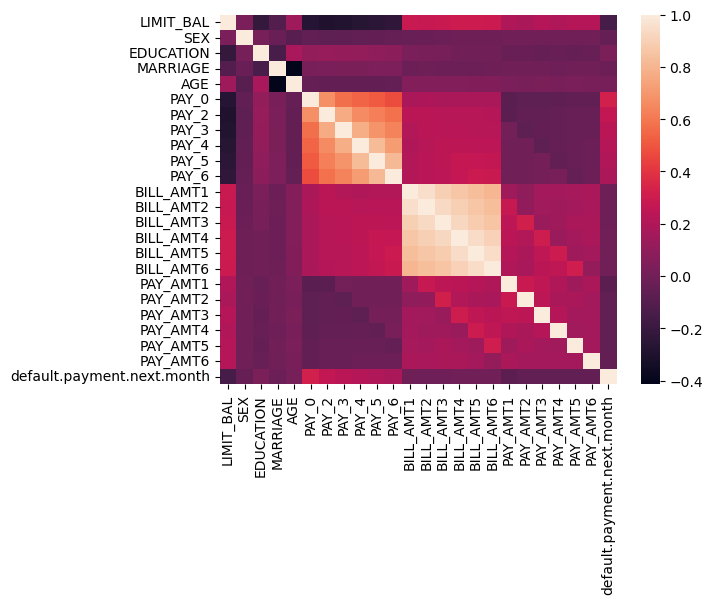

In [50]:
sns.heatmap(df.corr())

### Feature Engineering

In [ ]:
df = df.drop(columns=["ID"])

In [52]:
df["SEX"].unique()

array([2, 1])

In [53]:
df["MARRIAGE"].unique()

array([1, 2, 3, 0])

In [60]:
cols = ["MARRIAGE", "SEX", "EDUCATION"]

In [64]:
df = pd.get_dummies(df, columns=["MARRIAGE", "SEX", "EDUCATION"], drop_first=True)

In [65]:
df.head()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,...,True,False,False,True,False,True,False,False,False,False
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,...,False,True,False,True,False,True,False,False,False,False
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,...,False,True,False,True,False,True,False,False,False,False
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,...,True,False,False,True,False,True,False,False,False,False
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,...,True,False,False,False,False,True,False,False,False,False


### Model Kurulum

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC


In [69]:
X = df.drop(["default.payment.next.month"], axis= 1)
y = df["default.payment.next.month"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [71]:
scaler = StandardScaler()

In [72]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
model = SVC(probability= True)

In [104]:
model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [105]:
y_pred = model.predict(X_test_scaled)

In [106]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [107]:
print("score: ", accuracy_score(y_test, y_pred))
print("report: ", classification_report(y_test, y_pred))
print("matrix: ", confusion_matrix(y_test, y_pred))

score:  0.8195
report:                precision    recall  f1-score   support

           0       0.84      0.96      0.89      4687
           1       0.68      0.32      0.44      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000

matrix:  [[4491  196]
 [ 887  426]]


In [108]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

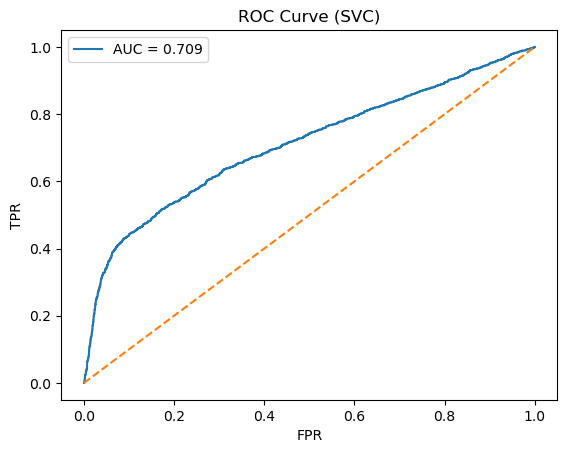

In [109]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (SVC)")
plt.legend()
plt.show()

In [114]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"],
    "class_weight": [None, "balanced"]
}

In [115]:
grid = GridSearchCV(param_grid = param_grid, estimator= model)

In [116]:
grid.fit(X_train_scaled, y_train)

,estimator,SVC(probability=True)
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': ['scale', 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10
